### STEP A. 데이터 준비

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
df = pd.read_csv('data/online_gaming_behavior_dataset.csv')

# 이탈 변수 생성
df['churn'] = df['EngagementLevel'].apply(lambda x:1 if x == 'Low' else 0)

# 범주형 변수 인코딩
le = LabelEncoder()
df['Gender_encoded']         = le.fit_transform(df['Gender'])
df['GameGenre_encoded']      = le.fit_transform(df['GameGenre'])
df['GameDifficulty_encoded'] = le.fit_transform(df['GameDifficulty'])

# 독립변수 선택
X = df[[
    'PlayTimeHours',
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'PlayerLevel',
    'AchievementsUnlocked',
    'InGamePurchases',
    'Gender_encoded',
    'GameGenre_encoded',
    'GameDifficulty_encoded'
]]
y = df['churn']

# 스케일링 (로지스틱 회귀는 스케일 영향 받음)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('독립변수 shape:', X.shape)
print('이탈률:', round(y.mean() * 100, 1), '%')

독립변수 shape: (40034, 9)
이탈률: 25.8 %


### STEP B. 학습/테스트 분리 + 모델 학습

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'학습 데이터: {len(X_train)}행')
print(f'테스트 데이터: {len(X_test)}헹')

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
print('\n모델 학습 완료!')

학습 데이터: 32027행
테스트 데이터: 8007헹

모델 학습 완료!


### STEP C. 변수 중요도(계수) 확인

[변수별 계수 - 양수: 이탈 증가, 음수: 이탈 감소]
                  feature  coefficient
            PlayTimeHours     0.017343
        GameGenre_encoded     0.006409
           Gender_encoded    -0.004763
   GameDifficulty_encoded    -0.004975
          InGamePurchases    -0.005080
              PlayerLevel    -0.310492
     AchievementsUnlocked    -0.324584
AvgSessionDurationMinutes    -1.399192
          SessionsPerWeek    -2.047713


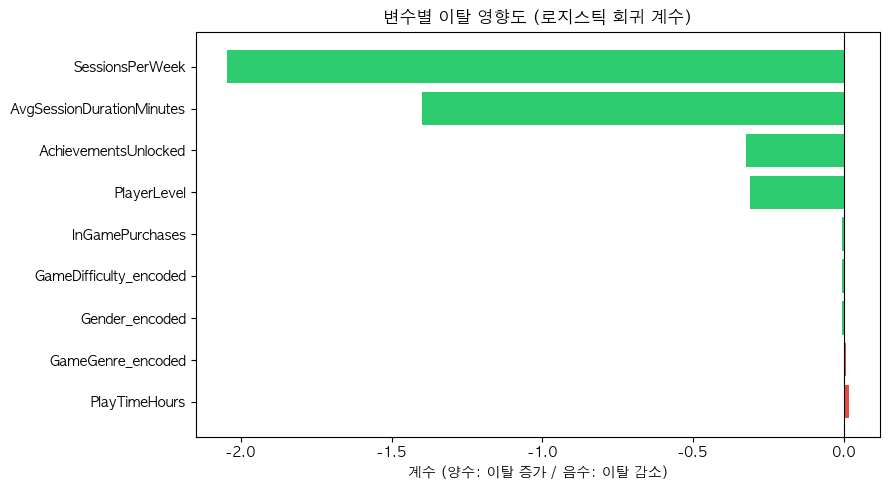

Optimization terminated successfully.
         Current function value: 0.327069
         Iterations 7
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: churn            Pseudo R-squared: 0.427     
Date:               2026-05-12 17:21 AIC:              26207.7274
No. Observations:   40034            BIC:              26293.7022
Df Model:           9                Log-Likelihood:   -13094.   
Df Residuals:       40024            LL-Null:          -22853.   
Converged:          1.0000           LLR p-value:      0.0000    
No. Iterations:     7.0000           Scale:            1.0000    
-------------------------------------------------------------------
          Coef.    Std.Err.      z       P>|z|     [0.025    0.975]
-------------------------------------------------------------------
const    -2.0825     0.0228   -91.3723   0.0000   -2.1272   -2.0378
x1        0.0181     0.0156     1.1655   0.2438   -0.0124 

In [15]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print('[변수별 계수 - 양수: 이탈 증가, 음수: 이탈 감소]')
print(coef_df.to_string(index=False))

plt.figure(figsize=(9, 5))
colors = ['#E74C3C' if c > 0 else '#2ECC71' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('변수별 이탈 영향도 (로지스틱 회귀 계수)')
plt.xlabel('계수 (양수: 이탈 증가 / 음수: 이탈 감소)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# 통계분석
import statsmodels.api as sm

# 상수항 추가
X_with_const = sm.add_constant(X_scaled)

# 로지스틱 회귀
logit_model = sm.Logit(y, X_with_const)
result = logit_model.fit()

print(result.summary2())

### STEP D. 모델 평가

[ 분류 리포트 ]
              precision    recall  f1-score   support

       잔존(0)       0.89      0.94      0.92      5942
       이탈(1)       0.81      0.68      0.74      2065

    accuracy                           0.88      8007
   macro avg       0.85      0.81      0.83      8007
weighted avg       0.87      0.88      0.87      8007



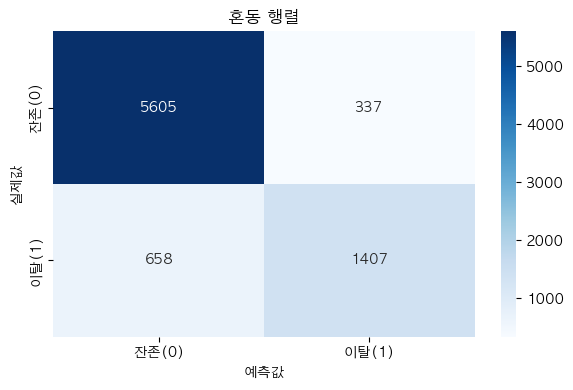

In [7]:
y_pred = model.predict(X_test)
print('[ 분류 리포트 ]')
print(classification_report(y_test, y_pred, target_names=['잔존(0)', '이탈(1)']))

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['잔존(0)', '이탈(1)'],
            yticklabels=['잔존(0)', '이탈(1)'])
plt.title('혼동 행렬')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

### STEP E. 이탈 위험 유저 세그먼트 정의

      risk_level  user_count   pct
0    저위험 (0~30%)        5416  67.6
2   중위험 (30~60%)        1199  15.0
1  고위험 (60~100%)        1392  17.4


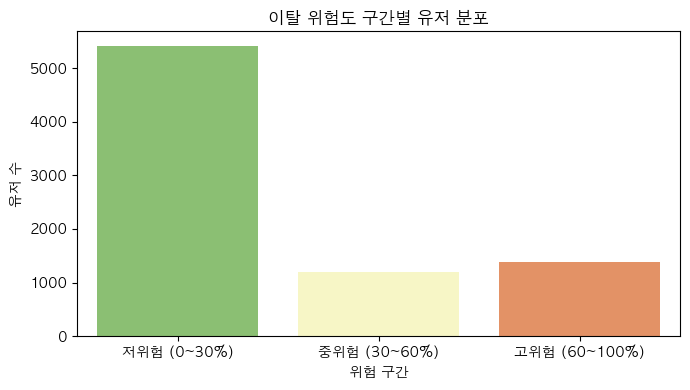

In [9]:
# 테스트 데이터에 예측 확률 추가
X_test_df = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=X.columns
)

X_test_df['churn_prob'] = model.predict_proba(X_test)[:, 1]
X_test_df['churn_actual'] = y_test.values

# 이탈 확률 구간별 유저 수
X_test_df['risk_level'] = pd.cut(
    X_test_df['churn_prob'],
    bins = [0, 0.3, 0.6, 1.0],
    labels = ['저위험 (0~30%)', '중위험 (30~60%)', '고위험 (60~100%)']
)

risk = X_test_df['risk_level'].value_counts().reset_index()
risk.columns = ['risk_level', 'user_count']
risk['pct'] = (risk['user_count'] / len(X_test_df) * 100).round(1)
print(risk.sort_values('risk_level'))

plt.figure(figsize=(7, 4))
sns.barplot(data=risk, x='risk_level', y='user_count', hue='risk_level', palette='RdYlGn_r')
plt.title('이탈 위험도 구간별 유저 분포')
plt.xlabel('위험 구간')
plt.ylabel('유저 수')
plt.tight_layout()
plt.savefig('risk_segment.png')
plt.show()





## 모델링 결론

### 변수 중요도 요약
- SessionsPerWeek 계수가 가장 큰 음수
  → 접속 빈도가 높을수록 이탈 확률 급감 (EDA 결과와 일치)
- AvgSessionDurationMinutes도 음의 계수
  → 세션 당 플레이 시간이 길수록 이탈 감소
- PlayTimeHours·InGamePurchases·GameDifficulty는 계수 작음
  → 이탈에 유의미한 영향 없음 (EDA 기각 가설과 일치)

### 비즈니스 액션 아이템
1. 주간 세션 수 2회 이하 유저를 이탈 위험군으로 조기 식별
   → 푸시 알림·이벤트·복귀 보상 등 리텐션 캠페인 우선 집행
2. 레벨 1~10 초반 구간 온보딩 경험 개선
   → 튜토리얼 강화, 초반 보상 증가로 접속 습관 형성
3. 고빈도·장시간 헤비유저(이탈률 3.1%) 유지 전략과
   저빈도·단시간 라이트유저(이탈률 63.7%) 전환 전략 분리 운영